In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [13]:
def txt_to_csv(fin, fout):
    fin = open(fin)
    fout = open(fout, 'w')
    L = fin.readlines()
    
    for s in L:
        inner_L = s.split()
        s = ','.join(inner_L) + '\n'
        fout.write(s)

In [14]:
txt_to_csv("PLANAR_AVERAGE.dat", "PLANAR_AVERAGE_MOD.txt")

In [15]:
class WF:
    def __init__(self, name, path, colour):
        txt_to_csv(f'{path}/PLANAR_AVERAGE.dat', f'{path}/PLANAR_AVERAGE_MOD.dat')
        dataset = pd.read_csv(f'{path}/PLANAR_AVERAGE_MOD.dat')
        wf = pd.read_csv(f'{path}/WF.txt', delimiter=":", header=None) 
        
        self.name = name
        self.X = dataset.iloc[:, 0].values
        self.Y = dataset.iloc[:, 1].values
        self.wf = dict(zip(wf.iloc[:, 0].values, wf.iloc[:, 1].values))
        self.colour = colour

In [16]:


        
def plot_workfunction(name, colour, X, Y, d):
    fig, ax = plt.subplots(figsize=(8, 6))

    ax.plot(X, Y, color=colour)
    
    ax.set_xlabel('Distance (A)')
    ax.set_ylabel('Planar-Average-Potential (eV)')

    # Set horizontal lines at the Vacuum level and the Fermi level (eV). Note this is E-fermi calculated in OUTCAR and accessed via 'grep E-fermi OUTCAR'
    # Workfunction is vacuum level - E-fermi 
    vacuum_level = d['Vacuum-Level']
    work_function = d['Work Function']
    fermi_level = vacuum_level - work_function
    ax.axhline(y=fermi_level, color='r', linestyle='dotted', linewidth=2, label=f'$E_F$ = {round(fermi_level, 3)} eV')
    ax.axhline(y=vacuum_level, color='purple', linestyle='dotted', linewidth=2, label=f'Vacuum-Level (eV) = {round(vacuum_level, 3)} eV')

    # Draw an arrow
    ax.annotate(
        "",  # No text
        xy=(6, vacuum_level),    
        xytext=(6, fermi_level),  
        arrowprops=dict(arrowstyle="->", color="black", linewidth=2),
    )

    # Add text at a specific point (without an arrow)
    ax.text(0.5, work_function-1, f"Work Function \n = {round(work_function, 3)} (eV)", fontsize=8, color=colour)

    ax.legend()
    plt.savefig(f'{name}_workfunction.png')
    plt.show()


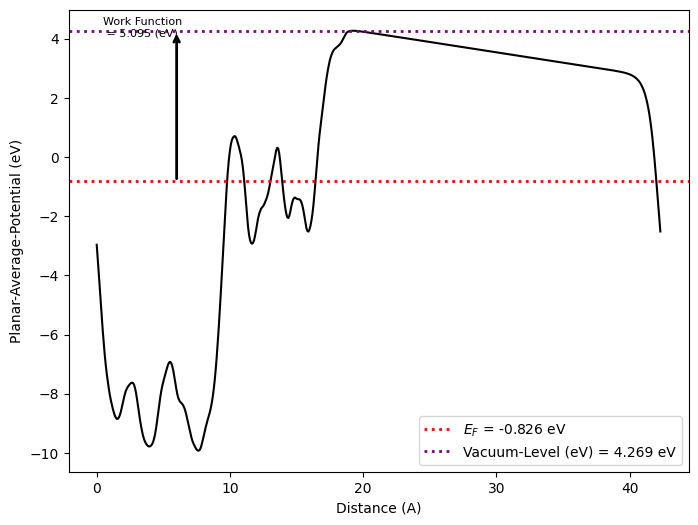

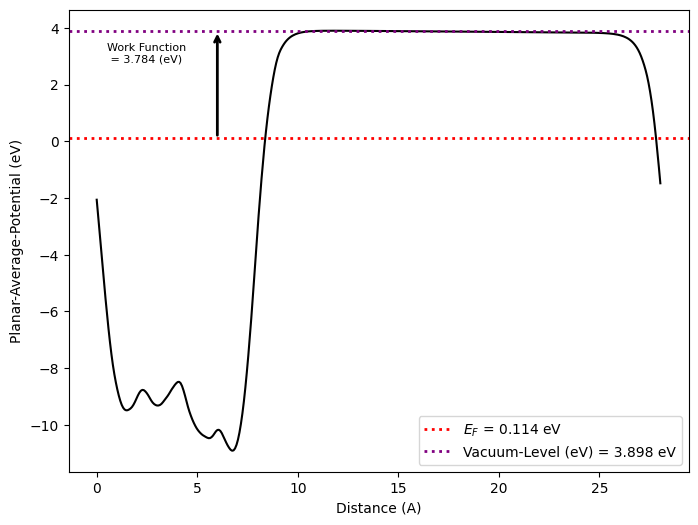

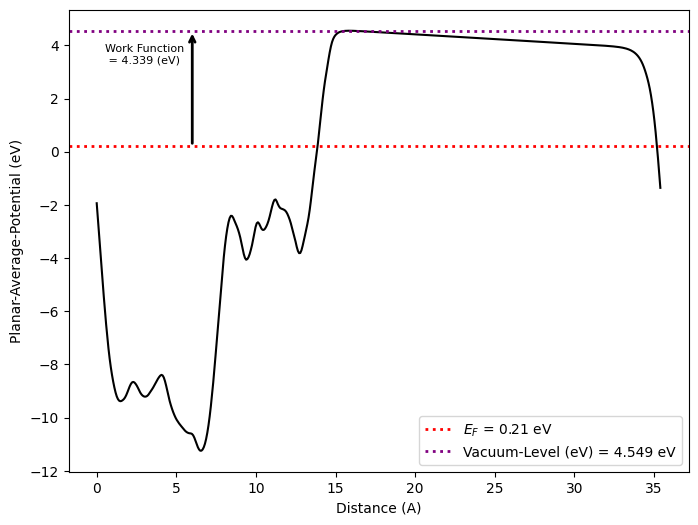

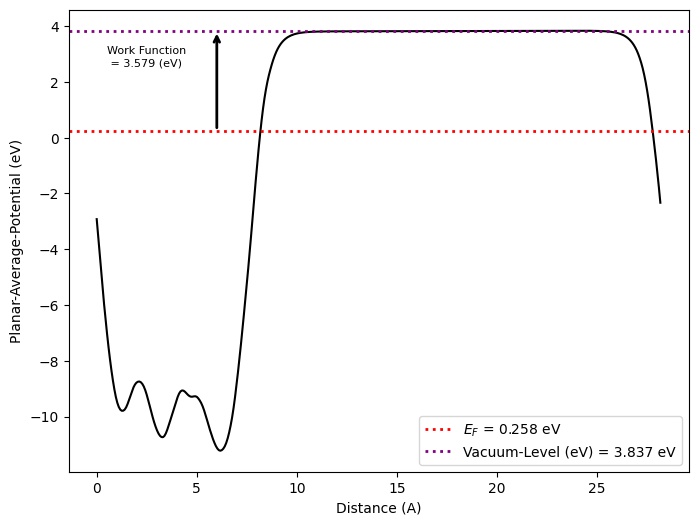

In [18]:
# Create a figure and axis



path = '/Users/agneskatai/cluster_data/Narval_test/NbTaMoW-FLiBe/dynamics/2_layer/salt/1ps_analysis/workfunction'
salt = WF('NbTaMoW + salt', path, 'black')
plot_workfunction(salt.name, salt.colour, salt.X, salt.Y, salt.wf)




path = '/Users/agneskatai/cluster_data/Narval_test/NbTaMoWV-FLiBe/dynamics/2_layer/no_salt/1ps_analysis/workfunction'
V_no_salt = WF('NbTaMoWV', path, 'black')
plot_workfunction(V_no_salt.name, V_no_salt.colour, V_no_salt.X, V_no_salt.Y, V_no_salt.wf)




path = '/Users/agneskatai/cluster_data/Narval_test/NbTaMoWV-FLiBe/dynamics/2_layer/salt/1ps_analysis/workfunction'
V_salt = WF('NbTaMoWV + salt', path, 'black')
plot_workfunction(V_salt.name, V_salt.colour, V_salt.X, V_salt.Y, V_salt.wf)


path = '/Users/agneskatai/cluster_data/Narval_test/NbTaMoW-FLiBe/dynamics/2_layer/no_salt/1ps_analysis/workfunction'
no_salt = WF('NbTaMoW', path, 'black')
plot_workfunction(no_salt.name, no_salt.colour, no_salt.X, no_salt.Y, no_salt.wf)





In [ ]:
dataset_salt = pd.read_csv("PLANAR_AVERAGE_MOD.txt")  # or use sep="\t"
wf_salt = pd.read_csv("WF.txt", delimiter=":", header=None)  # or use sep="\t"

result = dict(zip(wf_salt.iloc[:, 0].values, wf_salt.iloc[:, 1].values))


X2 = dataset.iloc[:, 0].values
Y2 = dataset.iloc[:, 1].values

plot_workfunction('salt', 'black', X, Y, result, fig, ax)

In [2]:
def calc_deriv(fin, fout):
    fin = open(fin)
    fout = open(fout, 'w')
    L = fin.readlines()
    inner_L1 = [float(s) for s in L[1].split()]
    inner_L2 = [float(s) for s in L[2].split()]

    x1, y1 = inner_L1[0], inner_L1[1]
    x2, y2 = inner_L2[0], inner_L2[1]
    
    min_deriv = abs((y2-y1)/(x2-x1))
    min_x, min_y = x1, y1 

    x1, y1 = x2, y2 
    
    for i in range(3, len(L)):
        inner_L = [float(s) for s in L[i].split()]
        x2, y2 = inner_L[0], inner_L[1]         # initial y-value
        

        deriv_1 = abs((y2-y1)/(x2-x1))
        print(deriv_1)

        if deriv_1 < min_deriv:
            min_deriv = deriv_1
            min_x, min_y = x1, y1 
             
        inner_L.append(deriv_1)
        s = ','.join([str(n) for n in inner_L]) + '\n'
        fout.write(s)

        x1, y1 = inner_L[0], inner_L[1]

    print(f'Smallest change occurs at {min_x}, {min_y}')
    return min_x, min_y

calc_deriv("PLANAR_AVERAGE.txt", "PLANAR_AVERAGE_DERIV.txt")

9.397961956521739
9.939348710990501
10.497554347826089
11.05135869565218
11.51385869565217
11.708559782608694
11.747761194029861
11.592798913043477
11.226766304347828
10.59497282608696
9.70664857530529
8.539266304347818
7.144293478260863
5.634239130434782
4.168070652173922
2.781546811397555
1.3846467391304391
0.004755434782597606
1.1936141304347783
2.277445652173902
3.3628222523744977
4.366440217391297
5.156114130434798
5.762228260869547
5.988059701492562
5.783967391304326
5.196875000000017
4.327309782608711
3.4456521739130106
2.7644504748982297
2.0558423913043575
1.1736413043478295
0.3444293478260812
0.24904891304346147
0.6626865671641852
1.097554347826092
1.518614130434784
1.968070652173915
2.2090909090909108
2.3230978260869617
2.427989130434775
2.3679347826086787
2.165081521739132
1.8184531886024584
1.3794836956521566
0.9570652173913247
0.6072010869565122
0.32282608695651127
0.11139755766621559
0.0838315217391181
0.3027173913043524
0.5202445652173913
0.8039348710990555
1.16114130434

(1.3252, -12.85702)

In [30]:
from py4vasp import Calculation
calc = Calculation.from_path("./no_salt/1ps_analysis/workfunction")

#pot_dict = calc.potential.read("default")

NoData: Cannot find the total potential data. Did you set LVTOT = T in the INCAR file?